# Railway Accident Severity Prediction using Machine Learning

## Let us check the columns first

In [ ]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Hussain\Downloads\railway_accidents.csv")

print(data.columns)

Index(['Year', 'Month', 'Day', 'Location', 'Casualties', 'Cause', 'Weather',
       'Train Speed', 'Maintenance Status', 'Signal Error'],
      dtype='object')


## 1. Importing Required Libraries

In [ ]:
# Importing required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## 2. Loading and Exploring Railway Accident Dataset

In [ ]:
# Loading Railway Accident Dataset

data = pd.read_csv(r"C:\Users\Hussain\Downloads\railway_accidents.csv")


print("RAILWAY ACCIDENT DATASET PREVIEW")
print(data.head())


print("\nDataset Shape:")
print(data.shape)


print("\nDataset Columns:")
print(data.columns)


print("\nDataset Information:")
print(data.info())


print("\nStatistical Description:")
print(data.describe())

RAILWAY ACCIDENT DATASET PREVIEW
   Year  Month  Day  Location  Casualties               Cause Weather  \
0  1998      1   27       844          31     Technical Fault   Clear   
1  1961      6   23       387          40         Human Error   Clear   
2  2018      2    7       506          22  Weather Conditions   Rainy   
3  2007      7   15       294          31         Human Error  Stormy   
4  1967      9   14       193          28     Technical Fault   Clear   

   Train Speed  Maintenance Status  Signal Error  
0    88.291400                   1             1  
1    46.087071                   0             0  
2    30.153011                   0             1  
3    72.348643                   0             1  
4    64.646958                   0             0  

Dataset Shape:
(100000, 10)

Dataset Columns:
Index(['Year', 'Month', 'Day', 'Location', 'Casualties', 'Cause', 'Weather',
       'Train Speed', 'Maintenance Status', 'Signal Error'],
      dtype='object')

Dataset Inform

## 3. Data Cleaning and Preprocessing

In [ ]:
# Checking Missing Values

print("\nMissing Values Before Cleaning:")
print(data.isnull().sum())


# Removing Missing Values

data = data.dropna()


print("\nMissing Values After Cleaning:")
print(data.isnull().sum())


# Creating Severity Levels

def create_severity(casualties):

    if casualties <= 10:
        return "Low"

    elif casualties <= 50:
        return "Medium"

    else:
        return "High"


data["Severity"] = data["Casualties"].apply(create_severity)


print("\nDataset After Adding Severity Column:")
print(data.head())


Missing Values Before Cleaning:
Year                  0
Month                 0
Day                   0
Location              0
Casualties            0
Cause                 0
Weather               0
Train Speed           0
Maintenance Status    0
Signal Error          0
dtype: int64

Missing Values After Cleaning:
Year                  0
Month                 0
Day                   0
Location              0
Casualties            0
Cause                 0
Weather               0
Train Speed           0
Maintenance Status    0
Signal Error          0
dtype: int64

Dataset After Adding Severity Column:
   Year  Month  Day  Location  Casualties               Cause Weather  \
0  1998      1   27       844          31     Technical Fault   Clear   
1  1961      6   23       387          40         Human Error   Clear   
2  2018      2    7       506          22  Weather Conditions   Rainy   
3  2007      7   15       294          31         Human Error  Stormy   
4  1967      9   14      

## 4. Railway Accident Severity Distribution Visualization

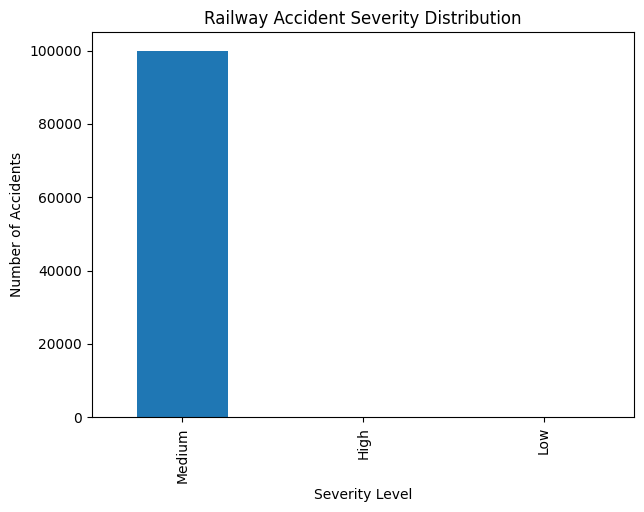

In [ ]:
plt.figure(figsize=(7,5))


data["Severity"].value_counts().plot(kind="bar")


plt.title("Railway Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")


plt.show()

## 5. Major Causes of Railway Accidents Visualization

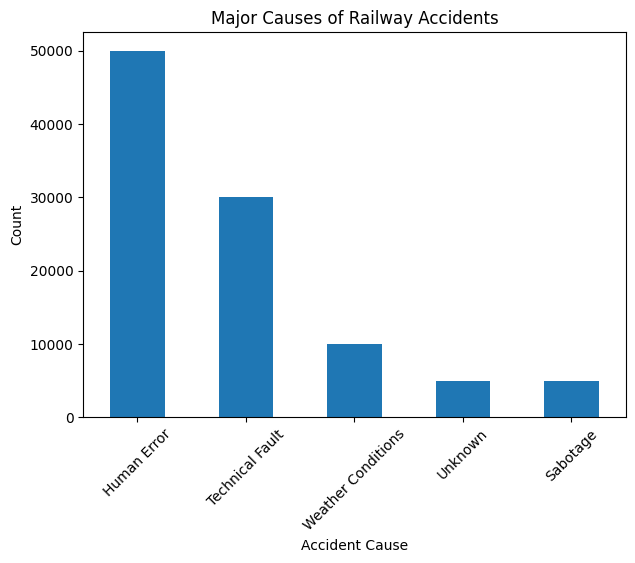

In [ ]:
plt.figure(figsize=(7,5))


data["Cause"].value_counts().head(5).plot(kind="bar")


plt.title("Major Causes of Railway Accidents")
plt.xlabel("Accident Cause")
plt.ylabel("Count")


plt.xticks(rotation=45)


plt.show()

## 6. Train Speed vs Casualties Analysis

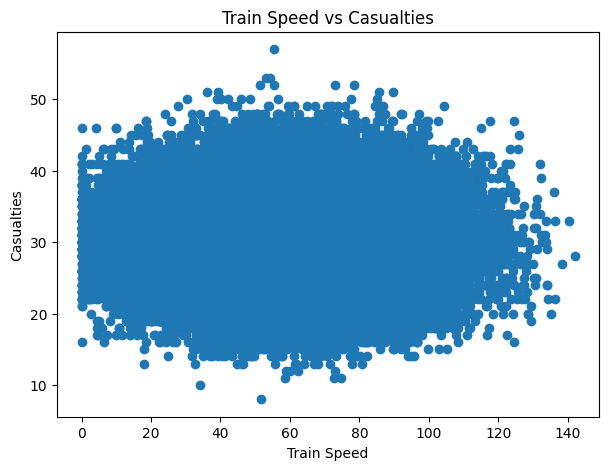

In [ ]:
plt.figure(figsize=(7,5))


plt.scatter(data["Train Speed"], data["Casualties"])


plt.title("Train Speed vs Casualties")
plt.xlabel("Train Speed")
plt.ylabel("Casualties")


plt.show()

## 7. Encoding Categorical Data

In [ ]:
# Encoding Categorical Values


encoder = LabelEncoder()


for column in data.columns:

    if data[column].dtype == "object":

        data[column] = encoder.fit_transform(data[column])


print("\nEncoded Dataset:")
print(data.head())


Encoded Dataset:
   Year  Month  Day  Location  Casualties  Cause  Weather  Train Speed  \
0  1998      1   27       844          31      2        0    88.291400   
1  1961      6   23       387          40      0        0    46.087071   
2  2018      2    7       506          22      4        2    30.153011   
3  2007      7   15       294          31      0        3    72.348643   
4  1967      9   14       193          28      2        0    64.646958   

   Maintenance Status  Signal Error  Severity  
0                   1             1         2  
1                   0             0         2  
2                   0             1         2  
3                   0             1         2  
4                   0             0         2  


## 8. Machine Learning Model Training Using Decision Tree Classifier

In [ ]:
# Splitting Features and Target


X = data.drop("Severity", axis=1)


y = data["Severity"]


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)


# Decision Tree Model


model = DecisionTreeClassifier()


model.fit(X_train, y_train)


print("Model Training Completed Successfully")

Model Training Completed Successfully


## 9. Railway Accident Severity Prediction

In [ ]:
# Prediction


y_pred = model.predict(X_test)


print("\nPredicted Severity Values:")


print(y_pred)


Predicted Severity Values:
[2 2 2 ... 2 2 2]


## 10. Model Performance Evaluation

In [ ]:
# Model Evaluation


accuracy = accuracy_score(y_test, y_pred)


print("\nMODEL ACCURACY:")


print(accuracy * 100)


print("\nCLASSIFICATION REPORT:")


print(classification_report(y_test, y_pred))


print("\nCONFUSION MATRIX:")


print(confusion_matrix(y_test, y_pred))


MODEL ACCURACY:
100.0

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           2       1.00      1.00      1.00     19999

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


CONFUSION MATRIX:
[[    1     0]
 [    0 19999]]


## 11. Sample Accident Severity Prediction Result

In [ ]:
# Sample Prediction

sample = X_test.iloc[0:1]

result = model.predict(sample)


if result[0] == 0:
    severity = "High Severity"

elif result[0] == 1:
    severity = "Low Severity"

else:
    severity = "Medium Severity"


print("\nSample Railway Accident Severity Prediction:")

print(severity)


Sample Railway Accident Severity Prediction:
Medium Severity


## Conclusion

The Machine Learning model successfully predicts railway accident severity levels by analyzing accident features such as casualties, causes, weather conditions, train speed, maintenance status, and signal errors.